In [2]:
import os
import platform
from datetime import datetime

os_info = f"{platform.system()} {platform.release()}"
timestamp = datetime.now().strftime("%d-%m-%Y %H:%M:%S")

print(f"Current OS: {os_info}")
print(f"Log Timestamp: {timestamp}")

Current OS: Linux 6.17.0-22-generic
Log Timestamp: 17-03-2026 20:43:23


# **Experiment 6: Data Analytics III**
1. Implement Simple Naïve Bayes classification algorithm using Python/R on iris.csv dataset.
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
    
dataset_path = os.path.join("datasets", "iris.csv")
df = pd.read_csv(dataset_path)

print(f"Dataset Shape: {df.shape}")
print(df.head())


Dataset Shape: (150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


### Data Preprocessing
Separating features and target. Since Iris is a multi-class dataset, we ensure the target is encoded if necessary, though GaussianNB handles it well.

In [2]:
# X = features (SepalLength, SepalWidth, PetalLength, PetalWidth)
# y = Species
X = df.drop('species', axis=1) if 'species' in df.columns else df.iloc[:, :-1]
y = df['species'] if 'species' in df.columns else df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model Training
Initializing the Gaussian NaÃ¯ve Bayes booster. This algorithm assumes features follow a normal distribution, which is a solid fit for the Iris subtasks.

In [3]:
classifier = GaussianNB()
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)


### Confusion Matrix & Performance Metrics
Note: For multi-class (3 species), the confusion matrix is 3x3. We calculate metrics using 'macro' or 'weighted' averaging to find the total efficiency.

--- Confusion Matrix ---
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Per-class Metrics:
TP: [10  9 11]
FP: [0 0 0]
TN: [20 21 19]
FN: [0 0 0]

Overall Performance:
Accuracy: 1.00
Error Rate: 0.00
Precision (Weighted): 1.00
Recall (Weighted): 1.00


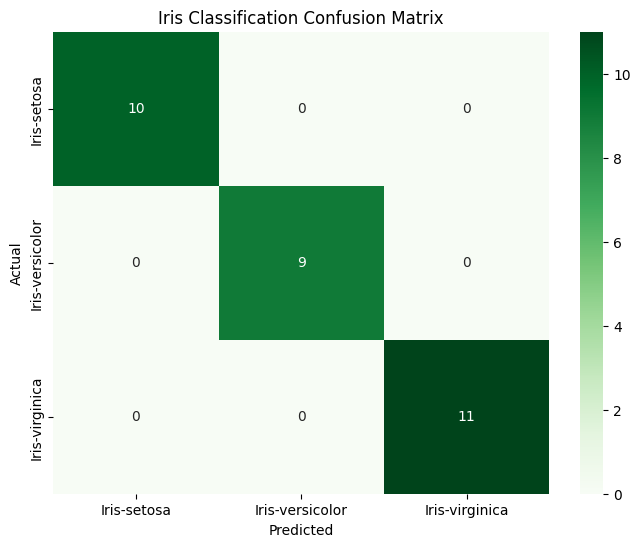

In [4]:
cm = confusion_matrix(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f"--- Confusion Matrix ---")
print(cm)

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

print(f"\nPer-class Metrics:")
print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"TN: {TN}")
print(f"FN: {FN}")

print(f"\nOverall Performance:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Error Rate: {error_rate:.2f}")
print(f"Precision (Weighted): {precision:.2f}")
print(f"Recall (Weighted): {recall:.2f}")

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap='Greens', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Iris Classification Confusion Matrix')
plt.show()
